## CSV 4: Inconsistent & Messy Date Formats (Temporal Chaos)

**Description**  
A merged sales export from multiple systems (CRM, marketing automation, ERP) containing mixed, partial, ambiguous, and invalid date formats within the same columns.

**Purpose / What It Tests**
- Robustness of date parsing and validation
- Detection and explanation of temporal issues
- Avoidance of silent row drops
- Correct time-based trend alignment (monthly, quarterly)
- Critical validation of sales trend accuracy


Dataset Generation

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(33)

N_ROWS = 2200

base_dates = pd.date_range("2023-01-01", "2024-12-31", freq="D")

products = ["CRM Pro", "Analytics Suite", "Sales Booster"]
regions = ["North America", "Europe", "Asia"]
stages = ["Won", "Lost", "Qualified"]

def random_date_string(dt):
    formats = [
        "%Y-%m-%d",        # 2024-03-15
        "%d/%m/%Y",        # 15/03/2024
        "%m-%d-%Y",        # 03-15-2024
        "%Y/%m/%d",        # 2024/03/15
        "%b %Y",           # Mar 2024
        "%Y-%m",           # 2024-03
    ]
    return dt.strftime(random.choice(formats))

rows = []

for i in range(N_ROWS):
    base_date = random.choice(base_dates)
    lead_date = base_date - timedelta(days=random.randint(5, 30))
    close_date = base_date + timedelta(days=random.randint(1, 20))

    # Introduce invalid dates
    order_date = (
        random_date_string(base_date)
        if random.random() > 0.05 else "32/13/2024"
    )

    rows.append({
        "order_id": f"O-{400000+i}",
        "order_date": order_date,          # 🚨 inconsistent
        "lead_date": random_date_string(lead_date),
        "close_date": random_date_string(close_date),
        "product": random.choice(products),
        "region": random.choice(regions),
        "revenue": random.randint(500, 20000),
        "units": random.randint(1, 15),
        "stage": random.choice(stages)
    })

df = pd.DataFrame(rows)

df.to_csv("sales_messy_dates.csv", index=False)
print("CSV generated: sales_messy_dates.csv")


CSV generated: sales_messy_dates.csv


Validation Code

In [2]:
import pandas as pd

df = pd.read_csv("sales_messy_dates.csv")

# Attempt naive parsing
parsed = pd.to_datetime(df["order_date"], errors="coerce")

invalid_ratio = parsed.isna().mean()
print("Invalid order_date ratio:", invalid_ratio)

# Confirm multiple date patterns exist
sample_dates = df["order_date"].dropna().head(20).tolist()
print("Sample date strings:", sample_dates)

assert invalid_ratio > 0.05, "❌ Not enough invalid/unparseable dates"
assert df["order_date"].dtype == object, "❌ order_date should be string/object"

print("✅ Inconsistent date format conditions validated.")


Invalid order_date ratio: 0.8454545454545455
Sample date strings: ['28/11/2023', '2024-07', '12-28-2023', '2024-11-29', '2023-04', '2024/12/12', '09/11/2023', '2023-03-11', '01-08-2023', '2024/11/11', 'May 2024', '12-18-2024', '2023/11/27', '06-01-2024', '2023-07-01', 'Nov 2023', '01-27-2023', '20/06/2024', 'Feb 2023', '2024-07']
✅ Inconsistent date format conditions validated.


C:\Users\KRONOS\AppData\Local\Temp\ipykernel_68724\2360885006.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  parsed = pd.to_datetime(df["order_date"], errors="coerce")


Gold Truth Analysis

C:\Users\KRONOS\AppData\Local\Temp\ipykernel_68724\426175033.py:7: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["order_date_parsed"] = pd.to_datetime(
C:\Users\KRONOS\AppData\Local\Temp\ipykernel_68724\426175033.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["order_date_parsed"] = pd.to_datetime(
C:\Users\KRONOS\AppData\Local\Temp\ipykernel_68724\426175033.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["revenue"]


Total Revenue (valid dates): 1076966
Dropped rows due to date issues: 0.9531818181818181


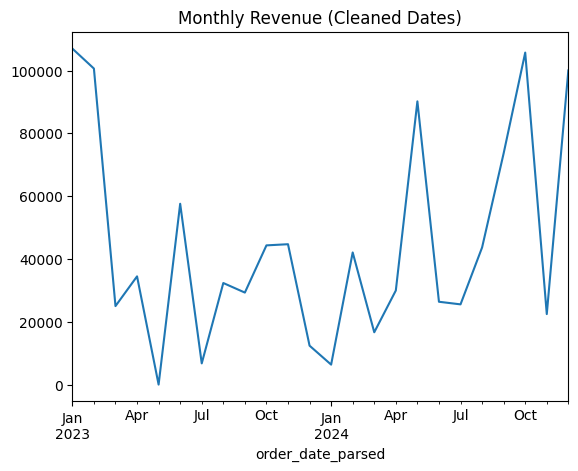

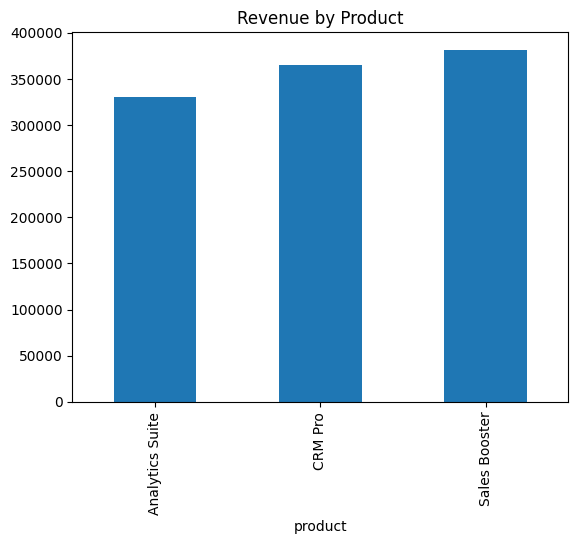

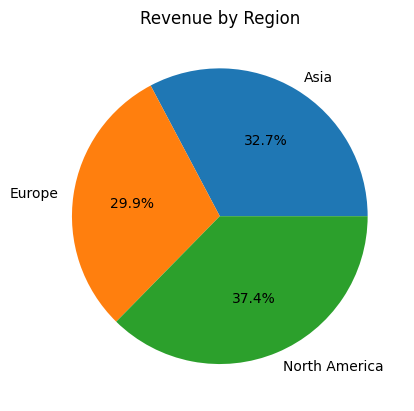

C:\Users\KRONOS\AppData\Local\Temp\ipykernel_68724\426175033.py:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["units"]


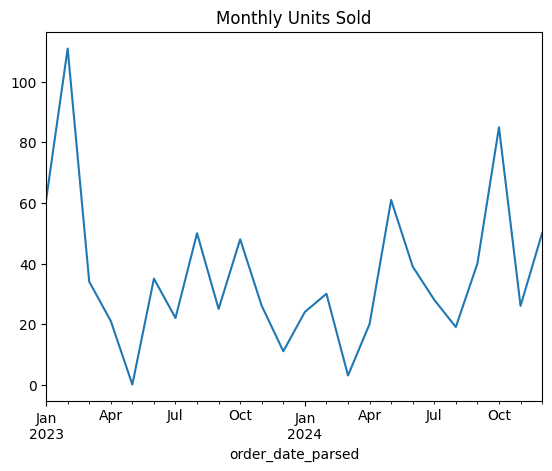

Average Revenue per Deal: 10455.980582524271


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_messy_dates.csv")

# Robust parsing
df["order_date_parsed"] = pd.to_datetime(
    df["order_date"],
    errors="coerce",
    infer_datetime_format=True
)

# Filter valid dates & won deals
valid = df[(df["order_date_parsed"].notna()) & (df["stage"] == "Won")]

# ---------------------------
# KPI 1: Total Revenue (valid dates only)
# ---------------------------
total_revenue = valid["revenue"].sum()
print("Total Revenue (valid dates):", total_revenue)

# ---------------------------
# KPI 2: % Rows Dropped Due to Date Issues
# ---------------------------
dropped_pct = 1 - (len(valid) / len(df))
print("Dropped rows due to date issues:", dropped_pct)

# ---------------------------
# Trend 1: Monthly Revenue Trend
# ---------------------------
monthly_revenue = (
    valid.set_index("order_date_parsed")
         .resample("M")["revenue"]
         .sum()
)

monthly_revenue.plot(title="Monthly Revenue (Cleaned Dates)")
plt.show()

# ---------------------------
# Trend 2: Revenue by Product
# ---------------------------
product_revenue = valid.groupby("product")["revenue"].sum()
product_revenue.plot(kind="bar", title="Revenue by Product")
plt.show()

# ---------------------------
# Trend 3: Revenue by Region
# ---------------------------
region_revenue = valid.groupby("region")["revenue"].sum()
region_revenue.plot(kind="pie", autopct="%1.1f%%", title="Revenue by Region")
plt.ylabel("")
plt.show()

# ---------------------------
# Trend 4: Units Sold Over Time
# ---------------------------
monthly_units = (
    valid.set_index("order_date_parsed")
         .resample("M")["units"]
         .sum()
)

monthly_units.plot(title="Monthly Units Sold")
plt.show()

# ---------------------------
# KPI 3: Average Revenue per Deal
# ---------------------------
avg_deal = valid["revenue"].mean()
print("Average Revenue per Deal:", avg_deal)
